## 1. Importando bibliotecas


In [1]:
import pandas as pd
import re
import os
import numpy as np


In [2]:
import sys

print(sys.executable)

/home/thaliaphotos/projetos/tcc_usp/education-digital-inequality-analysis/venv/bin/python


In [3]:
import polars as pl # na tentativa de usar o polars pE não quebrar o kernel. Ele não estava instalado, então instalei usando pip install polars, e agora estou importando ele para ver se funciona

print(pl.__version__)

1.40.1


In [4]:
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(200)

polars.config.Config

## 2. Criando conexão com DuckDB

Comando para reconhecer a pasta na raiz do projeto e conexão com o DuckBD

In [5]:
#os imports somente devem ser adicionados, caso o notebook não reconheça a coinfiguração do pythonpath 
# import os
# import sys

# sys.path.insert(0, os.path.abspath(".."))

from src.utils.database import get_duckdb_connection

con = get_duckdb_connection()


## 3. Listando todos os arquivos parquet da CETIC e Censo Escolar

Cetic Educação

In [6]:
arquivos_ed = con.execute("""
SELECT *
FROM glob('s3://trusted/cetic/educacao/2024/**/*.parquet')
""").fetchall()

for arq in arquivos_ed:
    print(arq[0])

s3://trusted/cetic/educacao/2024/b1_alunos_que_já_acessaram_a_internet.parquet
s3://trusted/cetic/educacao/2024/b6_alunos_por_dispositivos_utilizados_de_forma_exclusiva_para_acessar_a_internet.parquet
s3://trusted/cetic/educacao/2024/b9_alunos_por_local_de_acesso_à_internet.parquet
s3://trusted/cetic/educacao/2024/c1_alunos_por_presença_de_computador_no_domicílio.parquet
s3://trusted/cetic/educacao/2024/c5_alunos_que_receberam_computadores_da_escola_ou_de_órgãos_de_governo.parquet
s3://trusted/cetic/educacao/2024/d2_alunos_por_posse_de_telefone_celular.parquet
s3://trusted/cetic/educacao/2024/d5_1_alunos_que_receberam_chip_da_escola_ou_de_órgãos_de_governo.parquet
s3://trusted/cetic/educacao/2024/e1a_alunos_que_acessam_a_internet_na_escola_-_indicador_ampliado.parquet
s3://trusted/cetic/educacao/2024/e20_1_alunos_por_motivos_para_não_acessar_a_internet_na_escola.parquet
s3://trusted/cetic/educacao/2024/e2a_alunos_que_utilizaram_computadores_da_escola_para_acessar_a_internet_na_institui

Cetic domicílios

In [7]:
arquivos_dm = con.execute("""
SELECT *
FROM glob('s3://trusted/cetic/domicilios/2025/**/*.parquet')
""").fetchall()

for arq in arquivos_dm:
    print(arq[0])

s3://trusted/cetic/domicilios/2025/a10_domicílios_sem_acesso_à_internet_por_motivos_para_a_falta_de_internet.parquet
s3://trusted/cetic/domicilios/2025/a10a_domicílios_sem_acesso_à_internet_por_principal_motivo_para_a_falta_de_internet.parquet
s3://trusted/cetic/domicilios/2025/a11_domicílios_com_acesso_à_internet_por_valor_pago_pela_principal_conexão.parquet
s3://trusted/cetic/domicilios/2025/a12_domicílios_com_acesso_à_internet_por_presença_de_wi-fi.parquet
s3://trusted/cetic/domicilios/2025/a13_domicílios_com_acesso_à_internet_por_compartilhamento_com_domicílio_vizinho.parquet
s3://trusted/cetic/domicilios/2025/a1_domicílios_com_computador¹.parquet
s3://trusted/cetic/domicilios/2025/a4_domicílios_com_acesso_à_internet.parquet
s3://trusted/cetic/domicilios/2025/a4b_domicílios_por_presença_de_computador_e_internet¹.parquet
s3://trusted/cetic/domicilios/2025/a5_domicílios_com_acesso_à_internet_por_tipo_de_conexão.parquet
s3://trusted/cetic/domicilios/2025/a5a_domicílios_com_acesso_à_in

In [8]:
con.execute("""
DESCRIBE
SELECT *
FROM read_parquet(
    's3://trusted/cetic/domicilios/2025/a6a_domicílios_com_acesso_à_internet_por_velocidade_da_conexão.parquet'
)
""").pl()

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""Categoria""","""VARCHAR""","""YES""",null,null,null
"""Subcategoria""","""VARCHAR""","""YES""",null,null,null
"""Indicador""","""VARCHAR""","""YES""",null,null,null
"""Total""","""DOUBLE""","""YES""",null,null,null


In [22]:
arquivos = con.execute("""
SELECT *
FROM glob('s3://trusted/cetic/domicilios/2025/**/*.parquet')
""").fetchall()

for i, arq in enumerate(arquivos):
    print(i, arq[0])

0 s3://trusted/cetic/domicilios/2025/a10_domicílios_sem_acesso_à_internet_por_motivos_para_a_falta_de_internet.parquet
1 s3://trusted/cetic/domicilios/2025/a10a_domicílios_sem_acesso_à_internet_por_principal_motivo_para_a_falta_de_internet.parquet
2 s3://trusted/cetic/domicilios/2025/a11_domicílios_com_acesso_à_internet_por_valor_pago_pela_principal_conexão.parquet
3 s3://trusted/cetic/domicilios/2025/a12_domicílios_com_acesso_à_internet_por_presença_de_wi-fi.parquet
4 s3://trusted/cetic/domicilios/2025/a13_domicílios_com_acesso_à_internet_por_compartilhamento_com_domicílio_vizinho.parquet
5 s3://trusted/cetic/domicilios/2025/a1_domicílios_com_computador¹.parquet
6 s3://trusted/cetic/domicilios/2025/a4_domicílios_com_acesso_à_internet.parquet
7 s3://trusted/cetic/domicilios/2025/a4b_domicílios_por_presença_de_computador_e_internet¹.parquet
8 s3://trusted/cetic/domicilios/2025/a5_domicílios_com_acesso_à_internet_por_tipo_de_conexão.parquet
9 s3://trusted/cetic/domicilios/2025/a5a_domicí

In [23]:
arquivo = arquivos[0][0]

print(arquivo)

s3://trusted/cetic/domicilios/2025/a10_domicílios_sem_acesso_à_internet_por_motivos_para_a_falta_de_internet.parquet


In [24]:
query = f"""
SELECT *
FROM read_parquet('{arquivo}')
LIMIT 10
"""

df = con.execute(query).pl()

df

Categoria,Subcategoria,Indicador,Total
str,str,str,f64
"""TOTAL""","""Total""","""Por falta de computador no domicílio""",3.010035e6
"""ÁREA""","""Urbana""","""Por falta de computador no domicílio""",2.514414e6
"""ÁREA""","""Rural""","""Por falta de computador no domicílio""",495622.0
"""REGIÃO""","""Sudeste""","""Por falta de computador no domicílio""",1.270164e6
"""REGIÃO""","""Nordeste""","""Por falta de computador no domicílio""",874848.0
"""REGIÃO""","""Sul""","""Por falta de computador no domicílio""",299568.0
"""REGIÃO""","""Norte""","""Por falta de computador no domicílio""",392745.0
"""REGIÃO""","""Centro-Oeste""","""Por falta de computador no domicílio""",172710.0
"""RENDA FAMILIAR""","""Até 1 SM""","""Por falta de computador no domicílio""",1.760919e6


Censo Escolar

In [55]:

df_censo = con.execute("""
SELECT *
FROM read_parquet('s3://trusted/censo_escolar/*.parquet')
LIMIT 100000
""").pl()

df_censo.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CO_ENTIDADE,NU_ANO_CENSO,SG_UF,NO_MUNICIPIO,NO_REGIAO,TP_DEPENDENCIA,TP_LOCALIZACAO,IN_INTERNET,IN_INTERNET_ALUNOS,IN_BANDA_LARGA,IN_COMPUTADOR,IN_ACESSO_INTERNET_COMPUTADOR,IN_INTERNET_APRENDIZAGEM,IN_INTERNET_COMUNIDADE,IN_LABORATORIO_INFORMATICA,IN_DESKTOP_ALUNO,QT_DESKTOP_ALUNO,IN_COMP_PORTATIL_ALUNO,IN_COMP_PORTATIL_ALUNO_1,QT_COMP_PORTATIL_ALUNO,IN_TABLET_ALUNO,QT_TABLET_ALUNO,QT_MAT_BAS,QT_DOC_BAS,QT_DOC_BAS_DISC_INFO_COMPUTACAO
i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
23282860,2025,"""CE""","""Sobral""","""Nordeste""",3,1,1,0,1,1,0,1,0,1,0,0,0,0,0,0,0,269,15,0
23026138,2025,"""CE""","""Sobral""","""Nordeste""",3,2,1,0,1,1,0,0,0,0,1,7,0,0,0,1,4,258,9,0
23026154,2025,"""CE""","""Sobral""","""Nordeste""",3,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,421,18,0
23026162,2025,"""CE""","""Sobral""","""Nordeste""",3,2,1,0,1,1,0,1,0,1,0,0,1,1,25,1,3,178,11,0
23264101,2025,"""CE""","""Sobral""","""Nordeste""",2,2,1,1,1,1,1,1,0,1,1,20,1,1,5,1,186,325,28,0


## 4. Criando catálogo estruturado CETIC

**Com objetivo de separar automaticamente:**
- *bucket*
- *domínio*
- *ano*
- *nome da tabela*

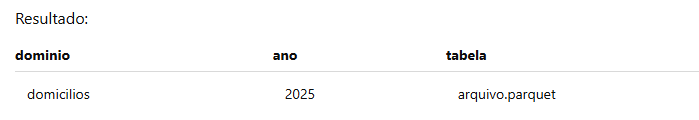

In [53]:
arquivos = con.execute("""
SELECT file
FROM glob('s3://trusted/cetic/**/*.parquet')
""").df()

print(arquivos["file"].str.contains("educacao").sum())
print(arquivos["file"].str.contains("domicilios").sum())

19
11


In [54]:
import polars as pl

catalogo = (
    pl.from_pandas(arquivos)   # importante se vier pandas
    .rename({"file": "caminho"})
    .with_columns([
        pl.col("caminho").str.split("/").alias("partes")
    ])
    .with_columns([
        pl.col("partes").list.get(4).alias("dominio"),
        pl.col("partes").list.get(5).alias("ano"),
        pl.col("partes").list.get(6).alias("arquivo")
    ])
    .drop("partes")
)
catalogo = catalogo.with_row_index("id")

catalogo

id,caminho,dominio,ano,arquivo
u32,str,str,str,str
0,"""s3://trusted/cetic/domicilios/2025/a10_domicílios_sem_acesso_à_internet_por_motivos_para_a_falta_de_internet.parquet""","""domicilios""","""2025""","""a10_domicílios_sem_acesso_à_internet_por_motivos_para_a_falta_de_internet.parquet"""
1,"""s3://trusted/cetic/domicilios/2025/a10a_domicílios_sem_acesso_à_internet_por_principal_motivo_para_a_falta_de_internet.parquet""","""domicilios""","""2025""","""a10a_domicílios_sem_acesso_à_internet_por_principal_motivo_para_a_falta_de_internet.parquet"""
2,"""s3://trusted/cetic/domicilios/2025/a11_domicílios_com_acesso_à_internet_por_valor_pago_pela_principal_conexão.parquet""","""domicilios""","""2025""","""a11_domicílios_com_acesso_à_internet_por_valor_pago_pela_principal_conexão.parquet"""
3,"""s3://trusted/cetic/domicilios/2025/a12_domicílios_com_acesso_à_internet_por_presença_de_wi-fi.parquet""","""domicilios""","""2025""","""a12_domicílios_com_acesso_à_internet_por_presença_de_wi-fi.parquet"""
4,"""s3://trusted/cetic/domicilios/2025/a13_domicílios_com_acesso_à_internet_por_compartilhamento_com_domicílio_vizinho.parquet""","""domicilios""","""2025""","""a13_domicílios_com_acesso_à_internet_por_compartilhamento_com_domicílio_vizinho.parquet"""
5,"""s3://trusted/cetic/domicilios/2025/a1_domicílios_com_computador¹.parquet""","""domicilios""","""2025""","""a1_domicílios_com_computador¹.parquet"""
6,"""s3://trusted/cetic/domicilios/2025/a4_domicílios_com_acesso_à_internet.parquet""","""domicilios""","""2025""","""a4_domicílios_com_acesso_à_internet.parquet"""
7,"""s3://trusted/cetic/domicilios/2025/a4b_domicílios_por_presença_de_computador_e_internet¹.parquet""","""domicilios""","""2025""","""a4b_domicílios_por_presença_de_computador_e_internet¹.parquet"""
8,"""s3://trusted/cetic/domicilios/2025/a5_domicílios_com_acesso_à_internet_por_tipo_de_conexão.parquet""","""domicilios""","""2025""","""a5_domicílios_com_acesso_à_internet_por_tipo_de_conexão.parquet"""


Ver quantidade de tabelas por Domínio

In [48]:
catalogo.group_by("dominio").agg(
    pl.len().alias("qtd_tabelas")
)

dominio,qtd_tabelas
str,u32
"""domicilios""",11
"""educacao""",19


In [49]:
catalogo.select([
    "id",
    "dominio",
    "ano",
    "arquivo"
]).sort("id")

for row in catalogo.select([
    "id",
    "arquivo"
]).iter_rows():

    print(row)

(0, 'a10_domicílios_sem_acesso_à_internet_por_motivos_para_a_falta_de_internet.parquet')
(1, 'a10a_domicílios_sem_acesso_à_internet_por_principal_motivo_para_a_falta_de_internet.parquet')
(2, 'a11_domicílios_com_acesso_à_internet_por_valor_pago_pela_principal_conexão.parquet')
(3, 'a12_domicílios_com_acesso_à_internet_por_presença_de_wi-fi.parquet')
(4, 'a13_domicílios_com_acesso_à_internet_por_compartilhamento_com_domicílio_vizinho.parquet')
(5, 'a1_domicílios_com_computador¹.parquet')
(6, 'a4_domicílios_com_acesso_à_internet.parquet')
(7, 'a4b_domicílios_por_presença_de_computador_e_internet¹.parquet')
(8, 'a5_domicílios_com_acesso_à_internet_por_tipo_de_conexão.parquet')
(9, 'a5a_domicílios_com_acesso_à_internet_por_meio_de_conexão_via_rede_móvel.parquet')
(10, 'a6a_domicílios_com_acesso_à_internet_por_velocidade_da_conexão.parquet')
(11, 'b1_alunos_que_já_acessaram_a_internet.parquet')
(12, 'b6_alunos_por_dispositivos_utilizados_de_forma_exclusiva_para_acessar_a_internet.parquet')


In [50]:
## aqui a genmte seleciiona qual o indice do catalogo definido acima
arquivo = catalogo[25, "caminho"]

print(arquivo)

s3://trusted/cetic/educacao/2024/g6_alunos_por_recursos_digitais_utilizados_em_pesquisas_e_atividades_escolares.parquet


In [ ]:
def read_parquet_minio(path, limit=1000):
    query = f"""
    SELECT *
    FROM read_parquet('{path}')
    LIMIT {limit}
    """

    return con.execute(query).pl()
df = read_parquet_minio(arquivo)
df.head() #(10).to_pandas()  # para mostrar as primeiras 10 linhas do dataframe usando pandas, e garantir já que o polars não tem um método head() que funcione diretamente no notebook.

Categoria,Subcategoria,Indicador,Total
str,str,str,f64
"""TOTAL""","""Total""","""Livros digitais ou disponíveis na Internet""",1.5705899e7
"""SEXO""","""Feminino""","""Livros digitais ou disponíveis na Internet""",8.901742e6
"""SEXO""","""Masculino""","""Livros digitais ou disponíveis na Internet""",6.804157e6
"""COR OU RAÇA""","""Branca""","""Livros digitais ou disponíveis na Internet""",5.691681e6
"""COR OU RAÇA""","""Preta""","""Livros digitais ou disponíveis na Internet""",1.625926e6


In [ ]:
arquivo = catalogo[10, "caminho"] ##  aqui é só ajustar o indice para escolher qual arquivo quer ler

df = read_parquet_minio(arquivo)

df

Categoria,Subcategoria,Indicador,Total
str,str,str,f64
"""TOTAL""","""Total""","""Até 4 Mbps""",2.897018e6
"""ÁREA""","""Urbana""","""Até 4 Mbps""",2.223523e6
"""ÁREA""","""Rural""","""Até 4 Mbps""",673495.0
"""REGIÃO""","""Sudeste""","""Até 4 Mbps""",951910.0
"""REGIÃO""","""Nordeste""","""Até 4 Mbps""",1.025965e6
…,…,…,…
"""RENDA FAMILIAR""","""Não respondeu""","""Não possui banda larga fixa""",633046.0
"""CLASSE SOCIAL""","""A""","""Não possui banda larga fixa""",18051.0
"""CLASSE SOCIAL""","""B""","""Não possui banda larga fixa""",999683.0


Arquivo Censo Escolar

In [ ]:
arquivos_censo = con.execute("""
SELECT *
FROM glob('s3://trusted/censo_escolar/**/*.parquet')
""").pl()

In [ ]:
catalogo_censo = (
    arquivos_censo
    .rename({"file": "caminho"})
    .with_row_index("id")
)

In [ ]:
arquivo = catalogo_censo[0, "caminho"]

df_censo = read_parquet_minio(arquivo)

df_censo.head()

NameError: name 'read_parquet_minio' is not defined

Como o Censo Escolar já está consolidado em uma tabela analítica, o maior problema agora é a interpretabilidade das variáveis
Ou seja:
- códigos numéricos
- siglas
- enums
- colunas crípticas do INEP

Então o ideal agora é criar o **Dicionário de Dados do Censo Escolar** com:

- nome da coluna
- descrição
- domínio
- mapeamento dos códigos
- transformação legível
E após isso incluir na refined.py

In [ ]:
dependencia_dict = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}